<a href="https://colab.research.google.com/github/pankajkumar8709/Machine-Learning-projects/blob/main/Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import kagglehub
import numpy as np
import pandas as pd

In [55]:
path=kagglehub.dataset_download("uciml/autompg-dataset")
path

Using Colab cache for faster access to the 'autompg-dataset' dataset.


'/kaggle/input/autompg-dataset'

In [56]:
import os
os.listdir(path)

['auto-mpg.csv']

In [57]:
df=pd.read_csv(path+"/auto-mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [58]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler,OneHotEncoder,OrdinalEncoder,LabelEncoder

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [60]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [61]:
x_train,x_test,y_train,y_test=train_test_split(df.drop("mpg",axis=1),df["mpg"],test_size=0.2,random_state=42)

In [62]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((318, 8), (80, 8), (318,), (80,))

In [63]:
x_train

,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
3,8,304.0,150,3433,12.0,70,1,amc rebel sst
18,4,97.0,88,2130,14.5,70,3,datsun pl510
376,4,91.0,68,2025,18.2,82,3,mazda glc custom l
248,4,91.0,60,1800,16.4,78,3,honda civic cvcc
177,4,115.0,95,2694,15.0,75,2,audi 100ls
...,...,...,...,...,...,...,...,...
71,3,70.0,97,2330,13.5,72,3,mazda rx2 coupe
106,8,350.0,180,4499,12.5,73,1,oldsmobile vista cruiser
270,4,134.0,95,2515,14.8,78,3,toyota celica gt liftback
348,4,89.0,62,2050,17.3,81,3,toyota tercel


In [67]:
x_train['car name'].unique()

array(['amc rebel sst', 'datsun pl510', 'mazda glc custom l',
       'honda civic cvcc', 'audi 100ls', 'pontiac catalina',
       'mazda glc deluxe', 'ford escort 2h', 'toyota carina',
       'mercury marquis brougham', 'chrysler cordoba', 'mazda rx-7 gs',
       'opel manta', 'renault 5 gtl', 'toyota mark ii',
       'plymouth horizon miser', 'dodge aries se', 'pontiac lemans v6',
       'dodge colt', 'plymouth satellite custom (sw)', 'ford fiesta',
       'datsun 610', 'amc hornet', 'amc ambassador sst', 'chevrolet nova',
       'plymouth fury iii', 'volkswagen 1131 deluxe sedan',
       'buick century luxus (sw)', 'volkswagen jetta', 'datsun 210 mpg',
       'toyota corolla 1200', 'fiat 131', 'chevrolet malibu classic (sw)',
       'honda civic (auto)', 'amc spirit dl', 'chevrolet vega',
       'renault 12 (sw)', 'dodge aspen 6', 'fiat strada custom',
       'peugeot 604sl', 'chevrolet bel air', 'ford maverick',
       'chevrolet malibu', 'amc gremlin', 'toyota cressida',
       'ma

In [66]:
x_test['car name'].unique()

array(['honda civic', 'ford ranger', 'amc gremlin',
       'plymouth volare premier v8', 'plymouth fury gran sedan',
       'toyota corolla 1600 (sw)', 'ford fairmont futura',
       'chrysler new yorker brougham', 'oldsmobile cutlass supreme',
       'ford maverick', 'amc ambassador dpl', 'plymouth cricket',
       'amc matador (sw)', 'chevrolet vega', 'dodge monaco (sw)',
       'pontiac j2000 se hatchback', 'volvo 264gl',
       'pontiac grand prix lj', 'mazda glc custom', 'volkswagen 411 (sw)',
       'plymouth duster', 'ford granada l', 'dodge colt m/m',
       'chevrolet chevelle malibu', 'vw pickup', 'fiat 124 sport coupe',
       'pontiac sunbird coupe', 'amc concord d/l', 'ford country',
       'ford mustang gl', 'volkswagen rabbit l', 'cadillac eldorado',
       'toyota corona hardtop', 'datsun 310', 'pontiac grand prix',
       'mercury capri v6', 'chevrolet monte carlo landau',
       'plymouth grand fury', 'audi fox', 'oldsmobile omega brougham',
       'volkswagen model 1

In [68]:
ohe=OneHotEncoder(drop='first',sparse_output=False,dtype=np.int32,handle_unknown='ignore')
x_train_new = ohe.fit_transform(x_train[['car name']])
x_test_new = ohe.transform(x_test[['car name']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [69]:
x_test_new = ohe.transform(x_test[['car name']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [70]:

x_train_new

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)

In [71]:
# Convert encoded array to DataFrame
encoded_df = pd.DataFrame(
    x_train_new,
    columns=ohe.get_feature_names_out(['car name']),
    index=x_train.index
)

# Drop original column
x_train = x_train.drop(columns=['car name'])

# Combine
x_train_trf = pd.concat([x_train, encoded_df], axis=1)


In [72]:
# Convert encoded array to DataFrame
encoded_df_test = pd.DataFrame(
    x_test_new,
    columns=ohe.get_feature_names_out(['car name']),
    index=x_test.index
)

# Drop original column
x_test = x_test.drop(columns=['car name'])

# Combine
x_test_trf = pd.concat([x_test, encoded_df_test], axis=1)


<class 'pandas.core.frame.DataFrame'>
Index: 318 entries, 3 to 102
Columns: 252 entries, cylinders to car name_vw rabbit custom
dtypes: float64(2), int32(245), int64(5)
memory usage: 324.2 KB


In [77]:
df['horsepower']=df['horsepower'].replace('?',np.nan)

In [78]:
df['horsepower'].fillna(df['horsepower'].mode()[0])

,horsepower
0,130
1,165
2,150
3,150
4,140
...,...
393,86
394,52
395,84
396,79


In [79]:
df['horsepower']=df['horsepower'].astype(int)

In [80]:
x_train_trf['horsepower']=df['horsepower']
x_test_trf['horsepower']=df['horsepower']

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = [ 'cylinders', 'displacement', 'horsepower',
            'weight', 'acceleration', 'model year']

x_train[num_cols] = scaler.fit_transform(x_train_trf[num_cols])
x_test[num_cols] = scaler.transform(x_test_trf[num_cols])

In [84]:
x_test_trf

,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name_amc ambassador sst,car name_amc concord,car name_amc concord dl,...,car name_volkswagen super beetle,car name_volkswagen type 3,car name_volvo 144ea,car name_volvo 244dl,car name_volvo 245,car name_volvo diesel,car name_vw dasher (diesel),car name_vw rabbit,car name_vw rabbit c (diesel),car name_vw rabbit custom
198,4,91.0,53,1795,17.4,76,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
396,4,120.0,79,2625,18.6,82,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
33,6,232.0,100,2634,13.0,71,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
208,8,318.0,150,3940,13.2,76,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
93,8,318.0,150,4237,14.5,73,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,8,260.0,110,3365,15.5,78,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
225,6,250.0,110,3520,16.4,77,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
367,4,112.0,88,2605,19.6,82,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
175,4,90.0,70,1937,14.0,75,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0


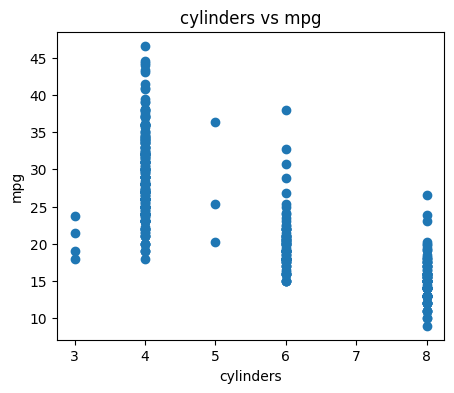

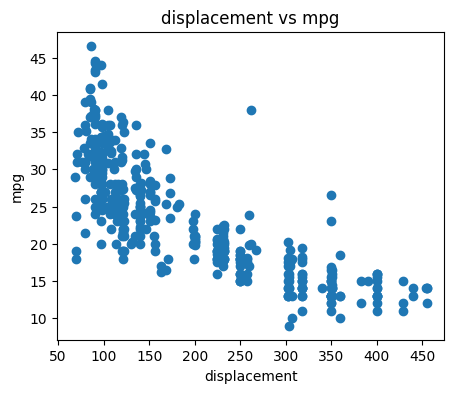

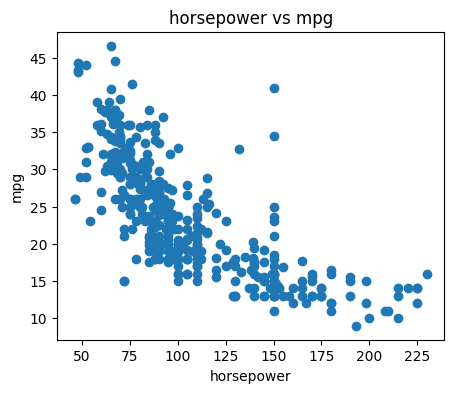

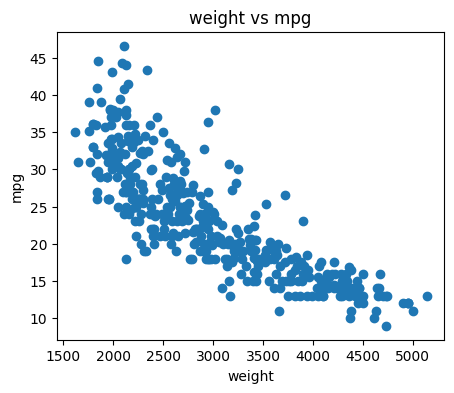

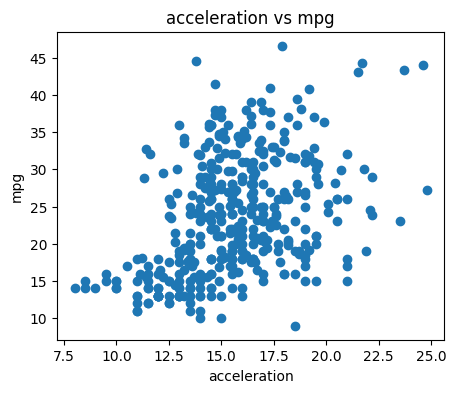

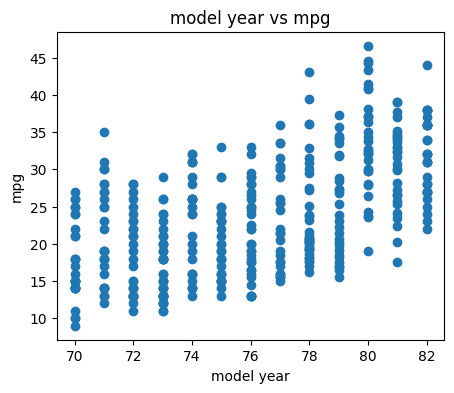

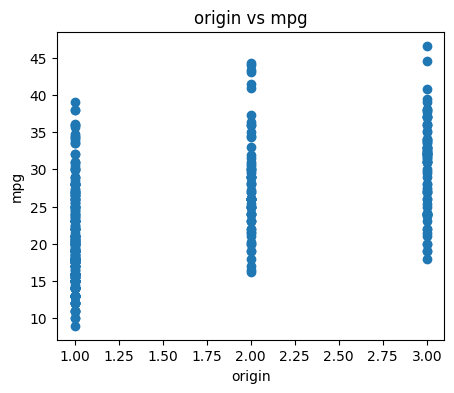

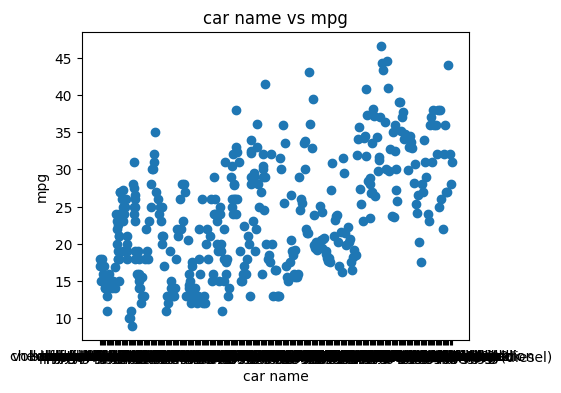

In [85]:
import matplotlib.pyplot as plt

target = 'mpg'   # Replace with your target column name

for col in df.columns:
    if col != target:
        plt.figure(figsize=(5,4))
        plt.scatter(df[col], df[target])
        plt.xlabel(col)
        plt.ylabel(target)
        plt.title(f'{col} vs {target}')
        plt.show()

In [87]:
lr=LinearRegression()
lr.fit(x_train_trf,y_train)

LinearRegression()

In [88]:
y_pred=lr.predict(x_test_trf)

In [89]:
r2_score(y_test,y_pred)

0.7537307050648405

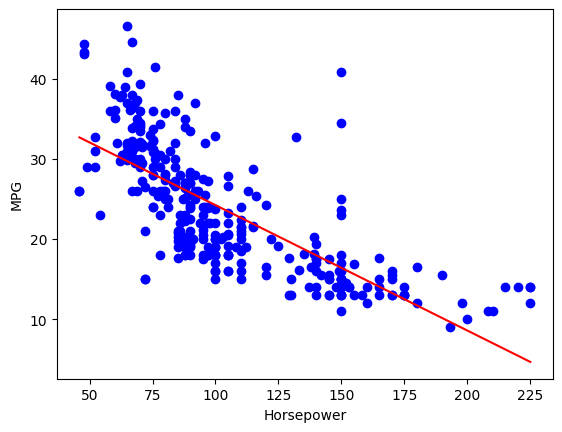

In [93]:
plt.scatter(x_train_trf['horsepower'], y_train, color='blue')

# Train a new simple linear regression model for 'horsepower' vs 'mpg'
lr_horsepower = LinearRegression()
lr_horsepower.fit(x_train_trf['horsepower'].values.reshape(-1, 1), y_train)

# Generate sorted 'horsepower' values for plotting the regression line
x_sorted_horsepower = np.sort(x_train_trf['horsepower'].values).reshape(-1, 1)
y_pred_horsepower = lr_horsepower.predict(x_sorted_horsepower)

plt.plot(x_sorted_horsepower, y_pred_horsepower, color='red')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()

In [129]:
poly=PolynomialFeatures(degree=3)
x_train_poly=poly.fit_transform(x_train_trf)
x_test_poly=poly.transform(x_test_trf)

In [130]:
x_train_poly.shape,x_test_poly.shape

((318, 2731135), (80, 2731135))

In [2]:
lr2=LinearRegression()
lr2.fit(x_train_poly,y_train)

NameError: name 'LinearRegression' is not defined

In [1]:
y_new=lr2.predict(x_test_poly)

NameError: name 'lr2' is not defined

In [127]:
r2_score(y_test,y_new)

-1.92706689318896

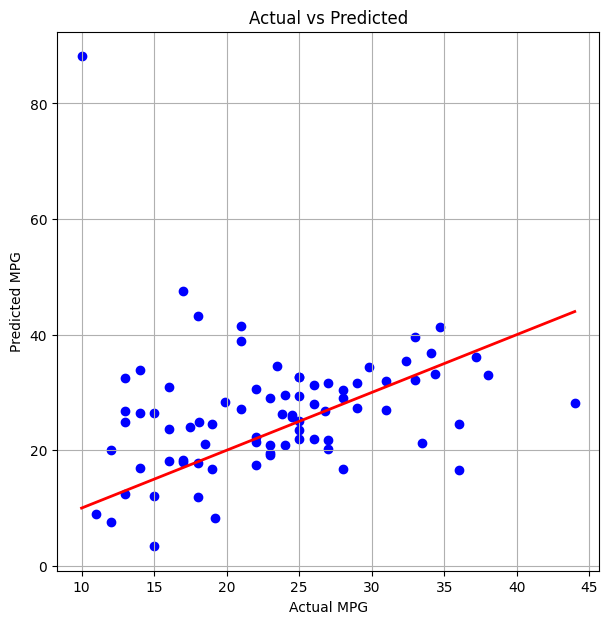

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_new, color='blue')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted")
plt.grid(True)

plt.show()